# Three-Gate SQR Duration Optimization

This notebook reuses the same 3 SQR gates from
`decomposition/cluster_U_T_1-1e+03ns-3_sqr-no_phases` and evaluates them with the
new multitone-Gaussian speed-limit workflow.

What this notebook does:
- loads the same three extracted SQR targets,
- sweeps SQR duration on a fixed grid,
- reports the minimum scanned duration that reaches a chosen fidelity threshold,
- compares the nominal pulse (no optimization corrections) against the optimized pulse,
- prints the optimized tone corrections used by the best solution for each gate.

The fidelity threshold and sweep grid are user-configurable below. The reported minimum
is the minimum **on the scanned grid**, not a continuous-time optimum.

In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from cqed_sim.analysis import SQRSpeedLimitConfig, TargetCase, evaluate_nominal_case, run_speedlimit_sweep_point
from cqed_sim.calibration.sqr import RandomSQRTarget
from cqed_sim.io.gates import SQRGate, load_gate_sequence, render_gate_table

np.set_printoptions(precision=6, suppress=True)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 120

## User Configuration

In [2]:
SEED = 1234
DECOMPOSITION_PATH = r"decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases"

# The threshold is intentionally user-editable. The notebook reports the minimum
# duration on the scanned grid that reaches this subspace fidelity.
FIDELITY_THRESHOLD = 0.98
DURATIONS_NS = (200, 300, 500, 750, 1000, 1500)
SIGMA_FRACTIONS = (0.16)

# This mirrors the low-lying matched subspace used for the three-gate study.
N_MATCH = 3
GUARD_LEVELS = 1
CHI_HZ = -2.84e6

# Runtime-balanced defaults. Increase these if you want a tighter search.
MULTISTART = 1
OPTIMIZER_MAXITER_STAGE1 = 3
OPTIMIZER_MAXITER_STAGE2 = 4
DT_S = 1.0e-9
MAX_STEP_S = 2.0e-9
QUTIP_NSTEPS = 100000

OUTPUT_ROOT = Path("outputs/sqr_three_gate_optimization")
REPORT_PATH = OUTPUT_ROOT / f"seed_{SEED}" / "three_gate_speedlimit_report.md"

## Load the Same Three SQR Gates

In [3]:
seq_path, gates = load_gate_sequence(DECOMPOSITION_PATH)
sqr_gates = [gate for gate in gates if isinstance(gate, SQRGate)]

print(f"Loaded sequence: {seq_path}")
print(f"Total gates: {len(gates)}")
print(f"SQR gates found: {len(sqr_gates)}")
render_gate_table(sqr_gates, max_rows=10)

assert len(sqr_gates) == 3, "Expected exactly three SQR gates in the decomposition file."

for gate in sqr_gates:
    theta = np.asarray(gate.theta, dtype=float)
    phi = np.asarray(gate.phi, dtype=float)
    active = np.where(np.abs(theta) > 1.0e-10)[0].tolist()
    print(f"\n{gate.name}")
    print("  theta[:6] =", theta[:6])
    print("  phi[:6]   =", phi[:6])
    print("  active target levels =", active)


Loaded sequence: decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases
Total gates: 10
SQR gates found: 3
  #  Type         Target   Name                                     Params
--------------------------------------------------------------------------
  2  SQR          qubit    SQR_527e17733de113ecaead4876b2bcafeb     tones=12, active=1
  5  SQR          qubit    SQR_bc8194a85a260be4c0959c6c4d8d7ae1     tones=12, active=1
  8  SQR          qubit    SQR_789278ba62949511b06e9d76a4bb8437     tones=12, active=1

SQR_527e17733de113ecaead4876b2bcafeb
  theta[:6] = [5.637238 0.       0.       0.       0.       0.      ]
  phi[:6]   = [1.545128 0.       0.       0.       0.       0.      ]
  active target levels = [0]

SQR_bc8194a85a260be4c0959c6c4d8d7ae1
  theta[:6] = [-4.121375  0.        0.        0.        0.        0.      ]
  phi[:6]   = [1.562768 0.       0.       0.       0.       0.      ]
  active target levels = [0]

SQR_789278ba62949511b06e9d76a4bb8437
  theta[:6] = [-4.603699  0

## Build Study Configuration and Helpers

In [4]:
study = SQRSpeedLimitConfig(
    seed=SEED,
    n_match=N_MATCH,
    guard_levels=GUARD_LEVELS,
    chi_hz=CHI_HZ,
    durations_ns=tuple(int(x) for x in DURATIONS_NS),
    sigma_fractions=tuple(float(x) for x in SIGMA_FRACTIONS),
    multistart=int(MULTISTART),
    dt_s=float(DT_S),
    max_step_s=float(MAX_STEP_S),
    optimizer_maxiter_stage1=int(OPTIMIZER_MAXITER_STAGE1),
    optimizer_maxiter_stage2=int(OPTIMIZER_MAXITER_STAGE2),
    qutip_nsteps_sqr_calibration=int(QUTIP_NSTEPS),
    output_root=OUTPUT_ROOT,
    report_path=REPORT_PATH,
)
output_dir = study.output_dir()
output_dir.mkdir(parents=True, exist_ok=True)
print("Output directory:", output_dir)
print("Study config:")
print(json.dumps(asdict(study), indent=2, default=str))


def make_case_from_gate(gate: SQRGate, gate_index: int, study_cfg: SQRSpeedLimitConfig) -> TargetCase:
    theta = tuple(float(x) for x in gate.theta[: study_cfg.logical_n]) + tuple(0.0 for _ in range(study_cfg.guard_levels))
    phi = tuple(float(x) for x in gate.phi[: study_cfg.logical_n]) + tuple(0.0 for _ in range(study_cfg.guard_levels))
    return TargetCase(
        name=f"gate_{gate_index:02d}",
        description=gate.name,
        target=RandomSQRTarget(
            target_id=gate.name,
            target_class="three_gate",
            logical_n=int(study_cfg.logical_n),
            guard_levels=int(study_cfg.guard_levels),
            theta=theta,
            phi=phi,
        ),
        phase="three_gate",
        composite_with_ideal_pi=False,
    )


def point_to_row(point: dict) -> dict:
    return {
        "duration_ns": float(point["duration_ns"]),
        "sigma_fraction": float(point["sigma_fraction"]),
        "subspace_fidelity": float(point["subspace_fidelity"]),
        "guard_selectivity_error": float(point["guard_selectivity_error"]),
        "logical_fidelity_weighted": float(point["logical_fidelity_weighted"]),
        "objective_loss_total": float(point["objective_loss_total"]),
        "selected_run_id": str(point["selected_run_id"]),
    }


def minimum_duration_row(rows: list[dict], threshold: float) -> dict | None:
    ordered = sorted(rows, key=lambda row: float(row["duration_ns"]))
    for row in ordered:
        if float(row["subspace_fidelity"]) >= float(threshold):
            return row
    return None


def calibration_table(point: dict) -> pd.DataFrame:
    rows = list(point["calibration_summary"].get("levels", []))
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    keep = [
        "n",
        "theta_target",
        "phi_target",
        "optimized_params",
        "process_fidelity",
        "initial_loss",
        "optimized_loss",
        "skipped",
    ]
    return df[keep]


def tone_table(waveform: dict) -> pd.DataFrame:
    tones = list(waveform.get("tones", []))
    if not tones:
        return pd.DataFrame(columns=["n", "amp_rad_s", "phase_rad", "omega_hz"])
    df = pd.DataFrame(tones).sort_values("n").reset_index(drop=True)
    df["amp_Mrad_s"] = df["amp_rad_s"] / 1.0e6
    df["omega_MHz"] = df["omega_hz"] / 1.0e6
    return df[["n", "amp_rad_s", "amp_Mrad_s", "phase_rad", "omega_hz", "omega_MHz"]]


def tone_comparison_table(nominal_waveform: dict, optimized_waveform: dict) -> pd.DataFrame:
    nominal = tone_table(nominal_waveform).rename(columns={
        "amp_rad_s": "amp_rad_s_nominal",
        "amp_Mrad_s": "amp_Mrad_s_nominal",
        "phase_rad": "phase_rad_nominal",
        "omega_hz": "omega_hz_nominal",
        "omega_MHz": "omega_MHz_nominal",
    })
    optimized = tone_table(optimized_waveform).rename(columns={
        "amp_rad_s": "amp_rad_s_optimized",
        "amp_Mrad_s": "amp_Mrad_s_optimized",
        "phase_rad": "phase_rad_optimized",
        "omega_hz": "omega_hz_optimized",
        "omega_MHz": "omega_MHz_optimized",
    })
    merged = nominal.merge(optimized, on="n", how="outer").sort_values("n").reset_index(drop=True)
    return merged


def plot_fidelity_sweeps(results: list[dict], threshold: float) -> None:
    fig, axes = plt.subplots(1, len(results), figsize=(5.0 * len(results), 4.0), sharey=True)
    if len(results) == 1:
        axes = [axes]
    for ax, result in zip(axes, results, strict=False):
        rows = sorted(result["sweep_rows"], key=lambda row: row["duration_ns"])
        durations = np.asarray([row["duration_ns"] for row in rows], dtype=float)
        fidelity = np.asarray([row["subspace_fidelity"] for row in rows], dtype=float)
        ax.plot(durations, fidelity, "o-", color="tab:blue", label="optimized")
        ax.axhline(float(threshold), color="tab:red", linestyle="--", linewidth=1.0, label="threshold")
        if result["threshold_row"] is not None:
            ax.axvline(float(result["threshold_row"]["duration_ns"]), color="0.5", linestyle=":", linewidth=1.0)
        ax.set_title(result["gate"].name)
        ax.set_xlabel("T_SQR [ns]")
        ax.set_ylabel("Subspace fidelity")
        ax.set_ylim(0.0, 1.01)
        ax.grid(alpha=0.25)
    axes[0].legend()
    fig.tight_layout()
    plt.show()


def plot_waveform_overlay(nominal_waveform: dict, optimized_waveform: dict, title: str) -> None:
    t_ns = np.asarray(optimized_waveform["tlist_s"], dtype=float) * 1.0e9
    fig, axes = plt.subplots(3, 1, figsize=(10.0, 7.0), sharex=True)
    axes[0].plot(t_ns, np.asarray(nominal_waveform["i"], dtype=float), color="0.6", linewidth=1.5, label="nominal")
    axes[0].plot(t_ns, np.asarray(optimized_waveform["i"], dtype=float), color="tab:blue", linewidth=1.5, label="optimized")
    axes[0].set_ylabel("I(t) [rad/s]")
    axes[1].plot(t_ns, np.asarray(nominal_waveform["q"], dtype=float), color="0.6", linewidth=1.5, label="nominal")
    axes[1].plot(t_ns, np.asarray(optimized_waveform["q"], dtype=float), color="tab:orange", linewidth=1.5, label="optimized")
    axes[1].set_ylabel("Q(t) [rad/s]")
    axes[2].plot(t_ns, np.asarray(nominal_waveform["magnitude"], dtype=float), color="0.6", linewidth=1.5, label="nominal")
    axes[2].plot(t_ns, np.asarray(optimized_waveform["magnitude"], dtype=float), color="tab:green", linewidth=1.5, label="optimized")
    axes[2].set_ylabel("|Omega(t)|")
    axes[2].set_xlabel("Time [ns]")
    for ax in axes:
        ax.grid(alpha=0.25)
    axes[0].legend(loc="upper right")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_spectrum_overlay(nominal_waveform: dict, optimized_waveform: dict, title: str) -> None:
    coeff_nom = np.asarray(nominal_waveform["coeff"], dtype=np.complex128)
    coeff_opt = np.asarray(optimized_waveform["coeff"], dtype=np.complex128)
    tlist = np.asarray(optimized_waveform["tlist_s"], dtype=float)
    if coeff_opt.size < 2:
        return
    dt = float(tlist[1] - tlist[0])
    freq_hz = np.fft.fftshift(np.fft.fftfreq(coeff_opt.size, d=dt)) / 1.0e6
    spec_nom = np.fft.fftshift(np.fft.fft(coeff_nom))
    spec_opt = np.fft.fftshift(np.fft.fft(coeff_opt))
    scale = max(float(np.max(np.abs(spec_nom))), float(np.max(np.abs(spec_opt))), 1.0e-18)
    fig, ax = plt.subplots(figsize=(10.0, 4.0))
    ax.plot(freq_hz, 20.0 * np.log10(np.abs(spec_nom) / scale + 1.0e-15), color="0.6", linewidth=1.4, label="nominal")
    ax.plot(freq_hz, 20.0 * np.log10(np.abs(spec_opt) / scale + 1.0e-15), color="tab:purple", linewidth=1.4, label="optimized")
    for tone in optimized_waveform.get("tones", []):
        ax.axvline(float(tone["omega_hz"]) / 1.0e6, color="0.5", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Normalized spectrum [dB]")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_selected_history(point: dict, title: str) -> None:
    history = list(point.get("history", []))
    if not history:
        print("No recorded history for", title)
        return
    df = pd.json_normalize(history)
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
    axes[0].plot(df["iteration"], df["objective_total"], color="tab:blue")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Objective")
    axes[0].grid(alpha=0.25)
    if "metrics.fidelity_subspace" in df.columns:
        axes[1].plot(df["iteration"], df["metrics.fidelity_subspace"], color="tab:green")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Subspace fidelity")
    axes[1].grid(alpha=0.25)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

TypeError: 'float' object is not iterable

## Run the Duration Sweep

In [ ]:
gate_results = []

for gate_index, gate in enumerate(sqr_gates, start=1):
    case = make_case_from_gate(gate, gate_index, study)
    case_dir = output_dir / f"gate_{gate_index:02d}_{case.name}"
    case_dir.mkdir(parents=True, exist_ok=True)

    sweep_rows = []
    point_payloads = {}
    print(f"\n=== Gate {gate_index}: {gate.name} ===")
    for duration_ns in study.durations_ns:
        point = run_speedlimit_sweep_point(
            case=case,
            duration_s=float(duration_ns) * 1.0e-9,
            study=study,
            point_output_dir=case_dir / f"T_{int(duration_ns):04d}ns",
        )
        point_payloads[int(duration_ns)] = point
        row = point_to_row(point)
        sweep_rows.append(row)
        print(
            f"  T={int(duration_ns):4d} ns | F={row['subspace_fidelity']:.6f} | "
            f"sigma={row['sigma_fraction']:.2f} | guard={row['guard_selectivity_error']:.3e}"
        )

    threshold_row = minimum_duration_row(sweep_rows, FIDELITY_THRESHOLD)
    if threshold_row is not None:
        selected_duration_ns = int(round(float(threshold_row["duration_ns"])))
        selection_reason = f"first duration reaching F >= {FIDELITY_THRESHOLD:.3f}"
    else:
        best_row = max(sweep_rows, key=lambda row: float(row["subspace_fidelity"]))
        selected_duration_ns = int(round(float(best_row["duration_ns"])))
        selection_reason = "threshold not reached on grid; using best scanned duration"

    selected_point = point_payloads[selected_duration_ns]
    nominal = evaluate_nominal_case(
        case=case,
        study=study,
        duration_s=float(selected_duration_ns) * 1.0e-9,
        sigma_fraction=float(selected_point["sigma_fraction"]),
    )
    gate_results.append(
        {
            "gate_index": int(gate_index),
            "gate": gate,
            "case": case,
            "case_dir": case_dir,
            "sweep_rows": sweep_rows,
            "point_payloads": point_payloads,
            "threshold_row": threshold_row,
            "selected_duration_ns": int(selected_duration_ns),
            "selected_point": selected_point,
            "nominal": nominal,
            "selection_reason": selection_reason,
        }
    )

summary_payload = {
    "seed": int(SEED),
    "fidelity_threshold": float(FIDELITY_THRESHOLD),
    "durations_ns": [int(x) for x in study.durations_ns],
    "sigma_fractions": [float(x) for x in study.sigma_fractions],
    "results": [
        {
            "gate_index": int(result["gate_index"]),
            "gate_name": result["gate"].name,
            "selected_duration_ns": int(result["selected_duration_ns"]),
            "selected_sigma_fraction": float(result["selected_point"]["sigma_fraction"]),
            "selected_fidelity": float(result["selected_point"]["subspace_fidelity"]),
            "baseline_fidelity": float(result["nominal"]["subspace_fidelity"]),
            "selection_reason": result["selection_reason"],
            "threshold_row": None if result["threshold_row"] is None else dict(result["threshold_row"]),
            "sweep_rows": list(result["sweep_rows"]),
        }
        for result in gate_results
    ],
}
summary_path = output_dir / "three_gate_summary.json"
summary_path.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")
print("\nWrote summary:", summary_path)


=== Gate 1: SQR_527e17733de113ecaead4876b2bcafeb ===
  T= 200 ns | F=0.598963 | sigma=0.30 | guard=1.044e-03
  T= 300 ns | F=0.764831 | sigma=0.30 | guard=2.076e-01
  T= 500 ns | F=0.863670 | sigma=0.30 | guard=5.372e-02
  T= 750 ns | F=0.929062 | sigma=0.30 | guard=8.608e-02
  T=1000 ns | F=0.933008 | sigma=0.20 | guard=1.702e-02

=== Gate 2: SQR_bc8194a85a260be4c0959c6c4d8d7ae1 ===
  T= 200 ns | F=0.829760 | sigma=0.30 | guard=2.357e-01
  T= 300 ns | F=0.898875 | sigma=0.30 | guard=1.170e-01
  T= 500 ns | F=0.952240 | sigma=0.30 | guard=1.711e-02
  T= 750 ns | F=0.493307 | sigma=0.30 | guard=3.763e-02
  T=1000 ns | F=0.493192 | sigma=0.30 | guard=3.833e-02

=== Gate 3: SQR_789278ba62949511b06e9d76a4bb8437 ===
  T= 200 ns | F=0.754802 | sigma=0.30 | guard=4.050e-03
  T= 300 ns | F=0.865549 | sigma=0.30 | guard=1.706e-01
  T= 500 ns | F=0.930937 | sigma=0.30 | guard=2.295e-02
  T= 750 ns | F=0.489726 | sigma=0.30 | guard=5.276e-02
  T=1000 ns | F=0.479316 | sigma=0.20 | guard=1.243e-0

## Minimum Duration Summary

In [ ]:
summary_rows = []
for result in gate_results:
    best_row = max(result["sweep_rows"], key=lambda row: float(row["subspace_fidelity"]))
    summary_rows.append(
        {
            "gate_index": int(result["gate_index"]),
            "gate_name": result["gate"].name,
            "target_theta_n0_rad": float(result["case"].target.theta[0]),
            "target_phi_n0_rad": float(result["case"].target.phi[0]),
            "min_duration_ns": None if result["threshold_row"] is None else float(result["threshold_row"]["duration_ns"]),
            "selected_duration_ns": float(result["selected_duration_ns"]),
            "selected_sigma_fraction": float(result["selected_point"]["sigma_fraction"]),
            "selected_fidelity": float(result["selected_point"]["subspace_fidelity"]),
            "baseline_fidelity_same_duration": float(result["nominal"]["subspace_fidelity"]),
            "fidelity_gain": float(result["selected_point"]["subspace_fidelity"] - result["nominal"]["subspace_fidelity"]),
            "best_scanned_duration_ns": float(best_row["duration_ns"]),
            "best_scanned_fidelity": float(best_row["subspace_fidelity"]),
            "selection_reason": result["selection_reason"],
        }
    )
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if summary_df["min_duration_ns"].notna().all():
    common_min_duration_ns = float(summary_df["min_duration_ns"].max())
    print(f"Common minimum scanned duration reaching F >= {FIDELITY_THRESHOLD:.3f} for all three gates: {common_min_duration_ns:.1f} ns")
else:
    print(f"At least one gate did not reach F >= {FIDELITY_THRESHOLD:.3f} on the scanned grid.")
    print("Use the selected_duration_ns column for the per-gate operating point chosen for waveform comparison.")

,gate_index,gate_name,target_theta_n0_rad,target_phi_n0_rad,min_duration_ns,selected_duration_ns,selected_sigma_fraction,selected_fidelity,baseline_fidelity_same_duration,fidelity_gain,best_scanned_duration_ns,best_scanned_fidelity,selection_reason
0,1,SQR_527e17733de113ecaead4876b2bcafeb,5.637238,1.545128,None,1000.0,0.2,0.933008,0.920270,0.012738,1000.0,0.933008,threshold not reached on grid; using best scan...
1,2,SQR_bc8194a85a260be4c0959c6c4d8d7ae1,-4.121375,1.562768,None,500.0,0.3,0.952240,0.937689,0.014551,500.0,0.952240,threshold not reached on grid; using best scan...
2,3,SQR_789278ba62949511b06e9d76a4bb8437,-4.603699,1.578716,None,500.0,0.3,0.930937,0.907311,0.023627,500.0,0.930937,threshold not reached on grid; using best scan...


At least one gate did not reach F >= 0.960 on the scanned grid.
Use the selected_duration_ns column for the per-gate operating point chosen for waveform comparison.


## Optimized Fidelity Sweep

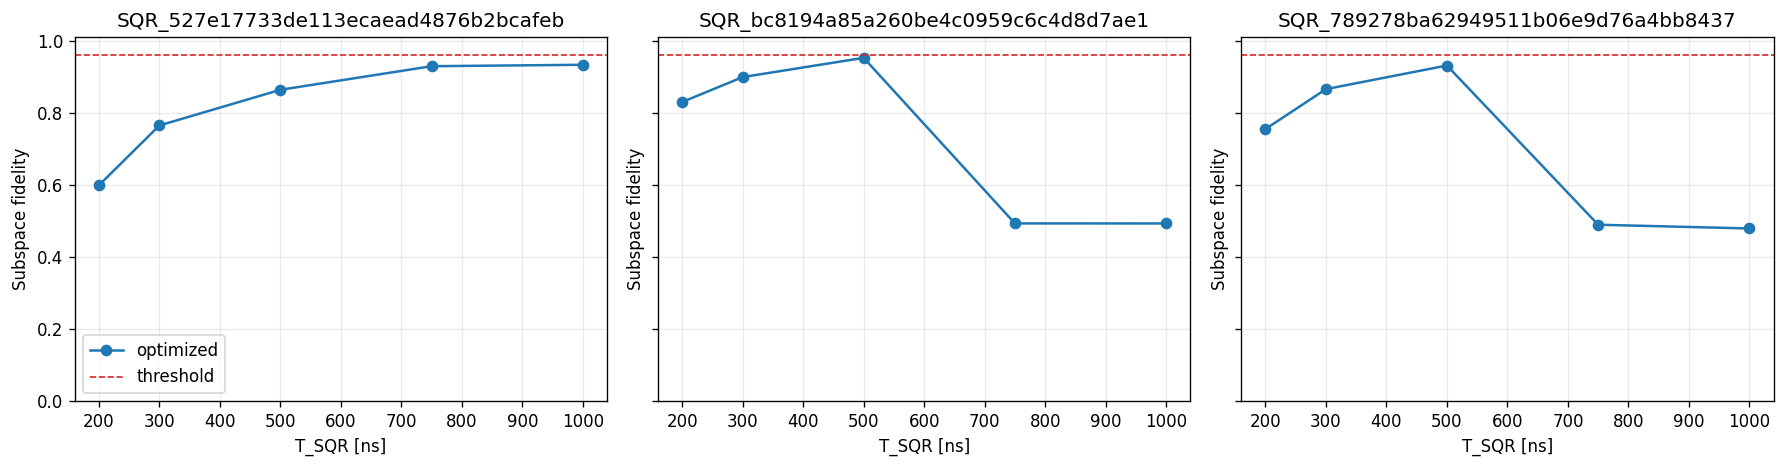

In [ ]:
plot_fidelity_sweeps(gate_results, FIDELITY_THRESHOLD)

## Optimized Parameters Per Gate

In [ ]:
for result in gate_results:
    display(Markdown(f"### Gate {result['gate_index']}: `{result['gate'].name}`"))
    print("Selection reason:", result["selection_reason"])
    print(
        "Selected point: "
        f"T={result['selected_duration_ns']} ns, "
        f"sigma={result['selected_point']['sigma_fraction']:.2f}, "
        f"F={result['selected_point']['subspace_fidelity']:.6f}, "
        f"guard={result['selected_point']['guard_selectivity_error']:.3e}"
    )
    display(calibration_table(result["selected_point"]))

### Gate 1: `SQR_527e17733de113ecaead4876b2bcafeb`

Selection reason: threshold not reached on grid; using best scanned duration
Selected point: T=1000 ns, sigma=0.20, F=0.933008, guard=1.702e-02


,n,theta_target,phi_target,optimized_params,process_fidelity,initial_loss,optimized_loss,skipped
0,0,5.637238,1.545128,"(-0.4998186429967946, -0.07259580430560686, 14...",0.960528,3.894414e-10,0.039472,False
1,1,0.000000,0.000000,"(-0.0019173988686445277, 0.33869165860479045, ...",0.734224,3.416180e-01,0.265776,False
2,2,0.000000,0.000000,"(0.02934659462504497, 0.6626298350213018, -361...",0.925616,9.863511e-02,0.074384,False
3,3,0.000000,0.000000,"(0.0, 0.0, 0.0)",0.966088,4.508478e-02,0.033912,True


### Gate 2: `SQR_bc8194a85a260be4c0959c6c4d8d7ae1`

Selection reason: threshold not reached on grid; using best scanned duration
Selected point: T=500 ns, sigma=0.30, F=0.952240, guard=1.711e-02


,n,theta_target,phi_target,optimized_params,process_fidelity,initial_loss,optimized_loss,skipped
0,0,-4.121375,1.562768,"(0.48745436961545524, -0.028720658496090404, 1...",0.933347,2.687002e-09,0.066653,False
1,1,0.000000,0.000000,"(-0.06644333122648044, 0.3005880570641742, -52...",0.831920,2.772488e-01,0.168080,False
2,2,0.000000,0.000000,"(-0.25367385840748125, 2.4362422025565285, -54...",0.957510,7.278655e-02,0.042490,False
3,3,0.000000,0.000000,"(0.0, 0.0, 0.0)",0.980194,3.291820e-02,0.019806,True


### Gate 3: `SQR_789278ba62949511b06e9d76a4bb8437`

Selection reason: threshold not reached on grid; using best scanned duration
Selected point: T=500 ns, sigma=0.30, F=0.930937, guard=2.295e-02


,n,theta_target,phi_target,optimized_params,process_fidelity,initial_loss,optimized_loss,skipped
0,0,-4.603699,1.578716,"(0.5, -0.063138862652683, 252749.9207041127)",0.928140,7.701726e-09,0.071860,False
1,1,0.000000,0.000000,"(-0.1504234370347838, 0.40249424994787153, -47...",0.750036,3.941863e-01,0.249964,False
2,2,0.000000,0.000000,"(-0.37191056823302154, 2.3800156417699307, -52...",0.928071,1.096357e-01,0.071929,False
3,3,0.000000,0.000000,"(0.0, 0.0, 0.0)",0.966798,5.040602e-02,0.033202,True


## Unoptimized Pulse vs Optimized Pulse

### Gate 1: `SQR_527e17733de113ecaead4876b2bcafeb`

Nominal fidelity at T=1000 ns: 0.920270 | Optimized fidelity: 0.933008


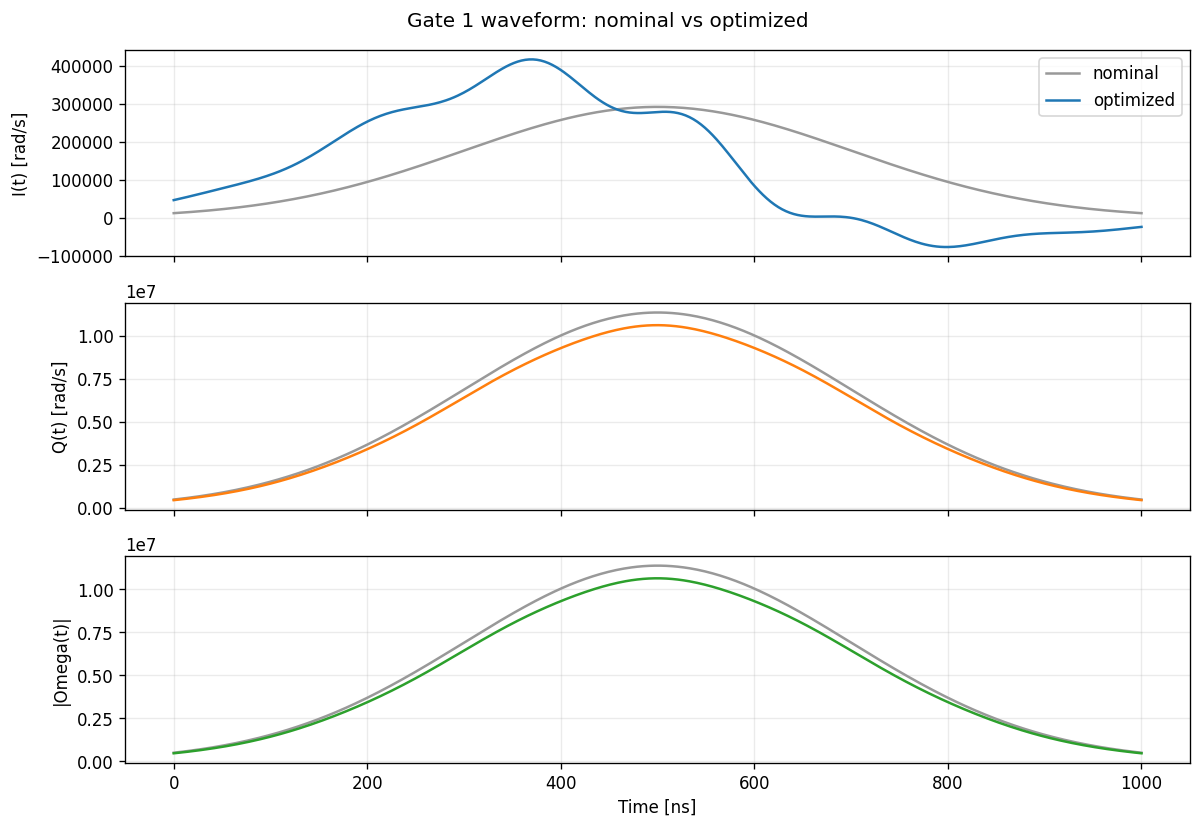

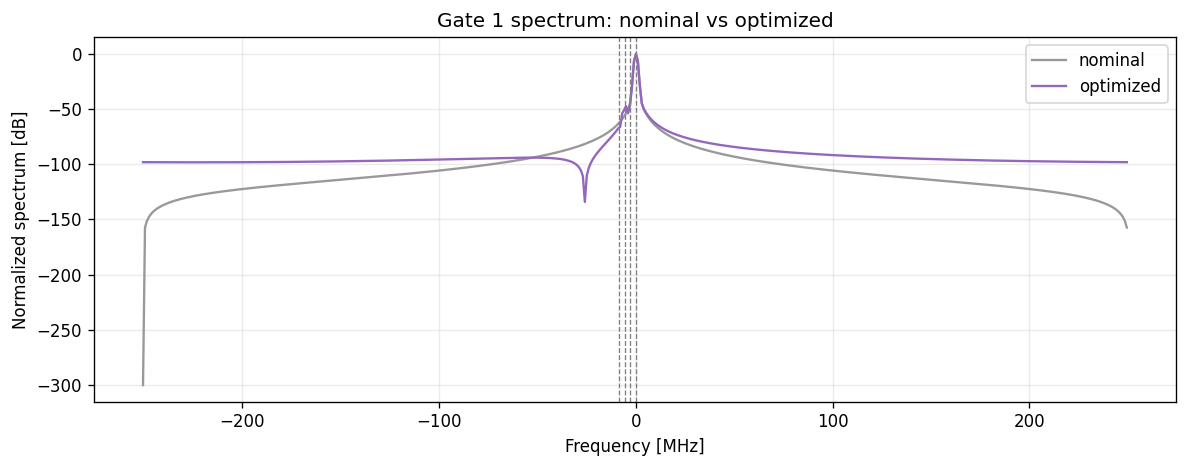

,n,amp_rad_s_nominal,amp_Mrad_s_nominal,phase_rad_nominal,omega_hz_nominal,omega_MHz_nominal,amp_rad_s_optimized,amp_Mrad_s_optimized,phase_rad_optimized,omega_hz_optimized,omega_MHz_optimized
0,0,1.138608e+07,11.386078,1.545128,0.0,0.00,1.060096e+07,10.600964,1.472532,2.309446e+04,0.023094
1,1,0.000000e+00,0.000000,0.000000,-2840000.0,-2.84,-3.011843e+03,-0.003012,0.338692,-2.894762e+06,-2.894762
2,2,0.000000e+00,0.000000,0.000000,-5680000.0,-5.68,4.609752e+04,0.046098,0.662630,-5.737600e+06,-5.737600
3,3,0.000000e+00,0.000000,0.000000,-8520000.0,-8.52,0.000000e+00,0.000000,0.000000,-8.520000e+06,-8.520000


### Gate 2: `SQR_bc8194a85a260be4c0959c6c4d8d7ae1`

Nominal fidelity at T=500 ns: 0.937689 | Optimized fidelity: 0.952240


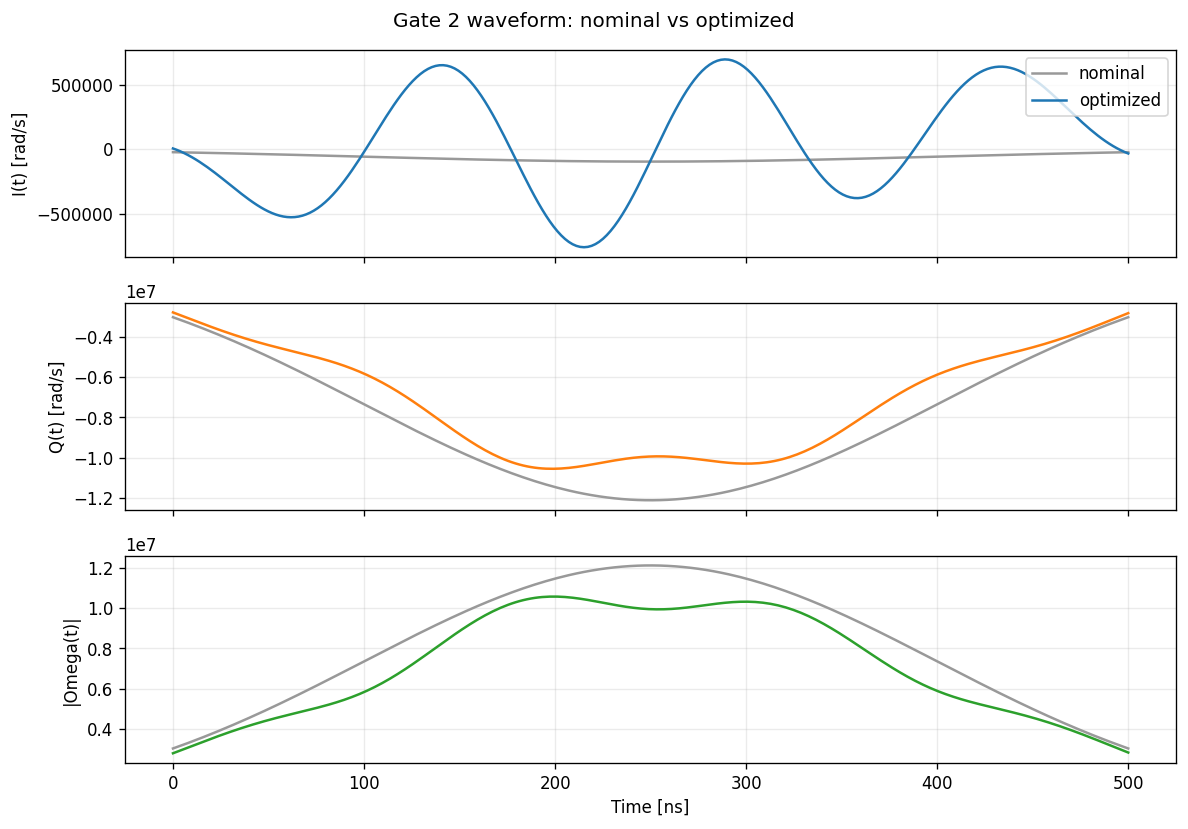

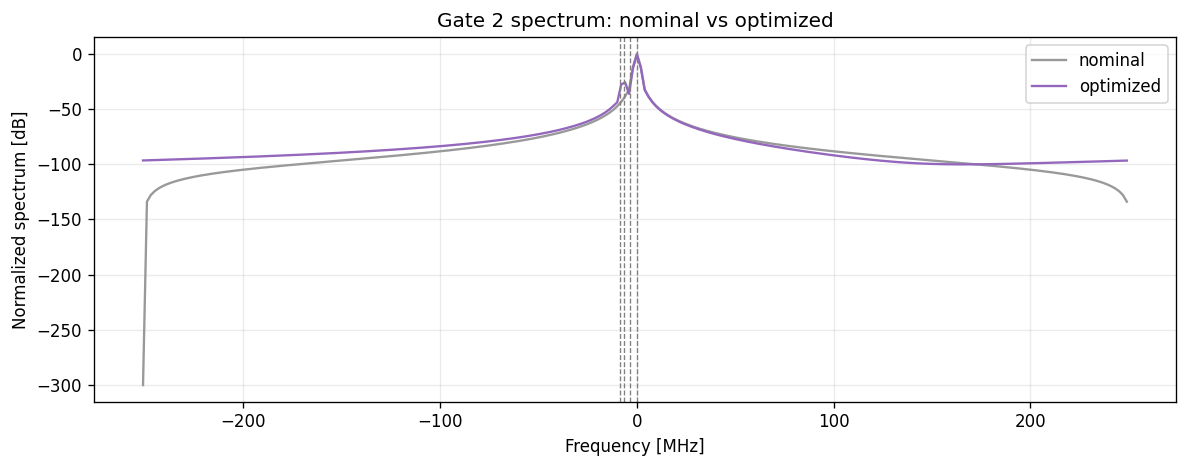

,n,amp_rad_s_nominal,amp_Mrad_s_nominal,phase_rad_nominal,omega_hz_nominal,omega_MHz_nominal,amp_rad_s_optimized,amp_Mrad_s_optimized,phase_rad_optimized,omega_hz_optimized,omega_MHz_optimized
0,0,-1.211974e+07,-12.119745,1.562768,0.0,0.00,-1.058836e+07,-10.588362,1.534047,2.699814e+04,0.026998
1,1,0.000000e+00,0.000000,0.000000,-2840000.0,-2.84,-2.087379e+05,-0.208738,0.300588,-3.667766e+06,-3.667766
2,2,0.000000e+00,0.000000,0.000000,-5680000.0,-5.68,-7.969399e+05,-0.796940,2.436242,-6.546858e+06,-6.546858
3,3,0.000000e+00,0.000000,0.000000,-8520000.0,-8.52,0.000000e+00,0.000000,0.000000,-8.520000e+06,-8.520000


### Gate 3: `SQR_789278ba62949511b06e9d76a4bb8437`

Nominal fidelity at T=500 ns: 0.907311 | Optimized fidelity: 0.930937


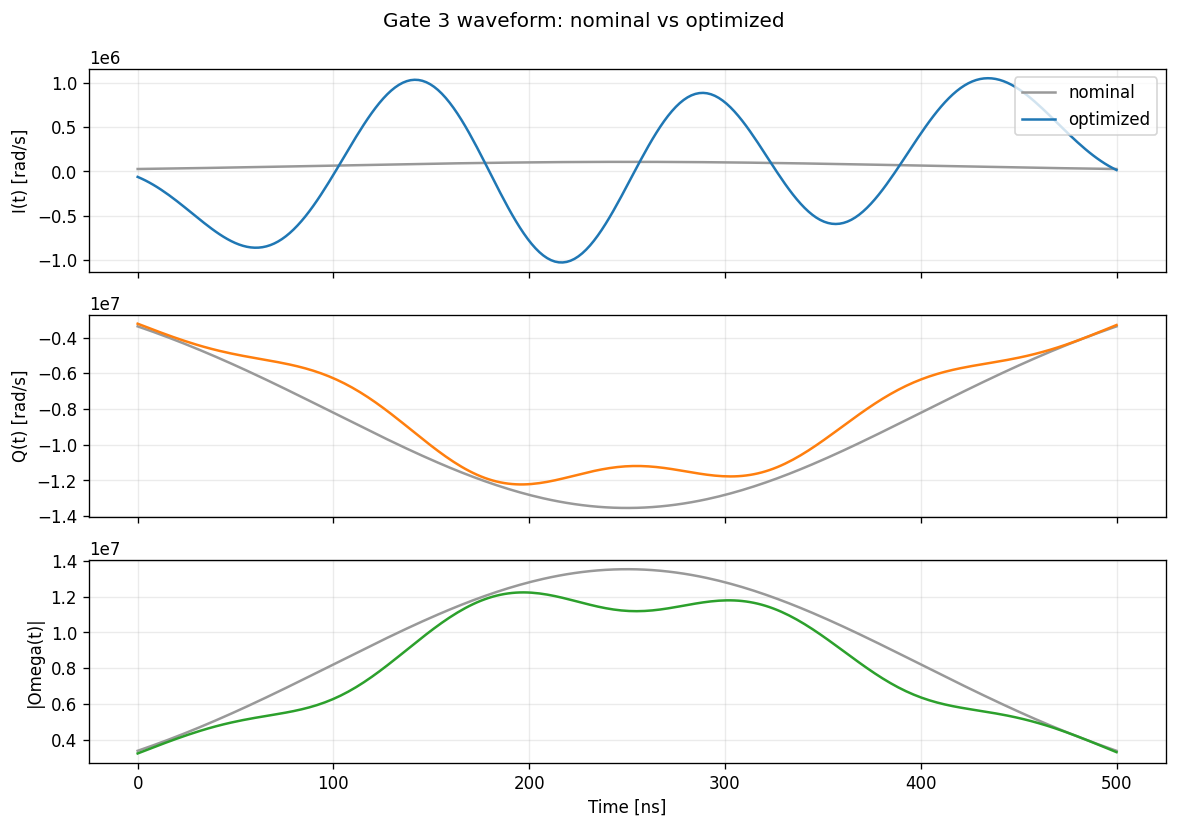

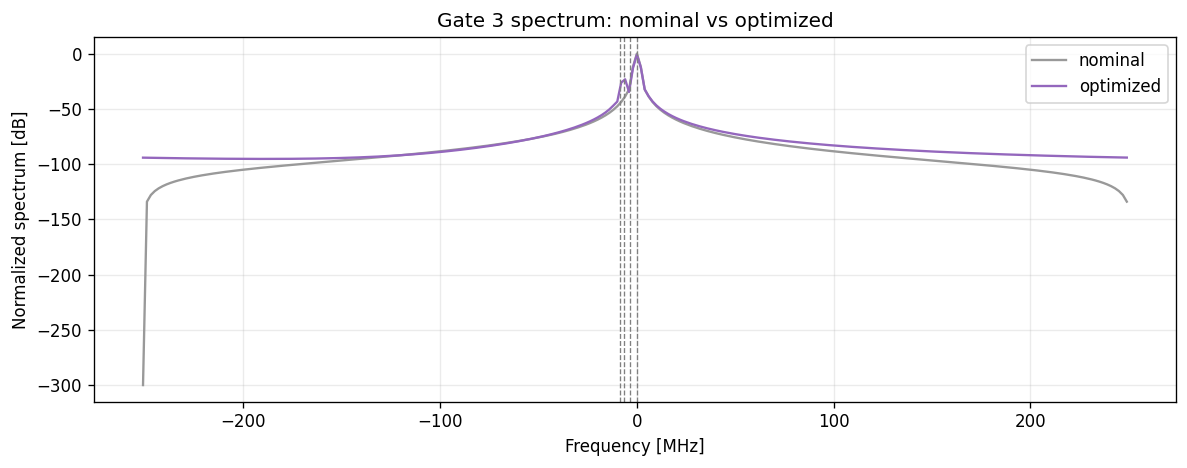

,n,amp_rad_s_nominal,amp_Mrad_s_nominal,phase_rad_nominal,omega_hz_nominal,omega_MHz_nominal,amp_rad_s_optimized,amp_Mrad_s_optimized,phase_rad_optimized,omega_hz_optimized,omega_MHz_optimized
0,0,-1.353812e+07,-13.538116,1.578716,0.0,0.00,-1.196732e+07,-11.967320,1.515577,4.022640e+04,0.040226
1,1,0.000000e+00,0.000000,0.000000,-2840000.0,-2.84,-4.725692e+05,-0.472569,0.402494,-3.601396e+06,-3.601396
2,2,0.000000e+00,0.000000,0.000000,-5680000.0,-5.68,-1.168392e+06,-1.168392,2.380016,-6.508828e+06,-6.508828
3,3,0.000000e+00,0.000000,0.000000,-8520000.0,-8.52,0.000000e+00,0.000000,0.000000,-8.520000e+06,-8.520000


In [ ]:
for result in gate_results:
    display(Markdown(f"### Gate {result['gate_index']}: `{result['gate'].name}`"))
    print(
        f"Nominal fidelity at T={result['selected_duration_ns']} ns: {result['nominal']['subspace_fidelity']:.6f} | "
        f"Optimized fidelity: {result['selected_point']['subspace_fidelity']:.6f}"
    )
    plot_waveform_overlay(
        result["nominal"]["waveform"],
        result["selected_point"]["waveform"],
        title=f"Gate {result['gate_index']} waveform: nominal vs optimized",
    )
    plot_spectrum_overlay(
        result["nominal"]["waveform"],
        result["selected_point"]["waveform"],
        title=f"Gate {result['gate_index']} spectrum: nominal vs optimized",
    )
    display(tone_comparison_table(result["nominal"]["waveform"], result["selected_point"]["waveform"]))

## Selected Optimization History

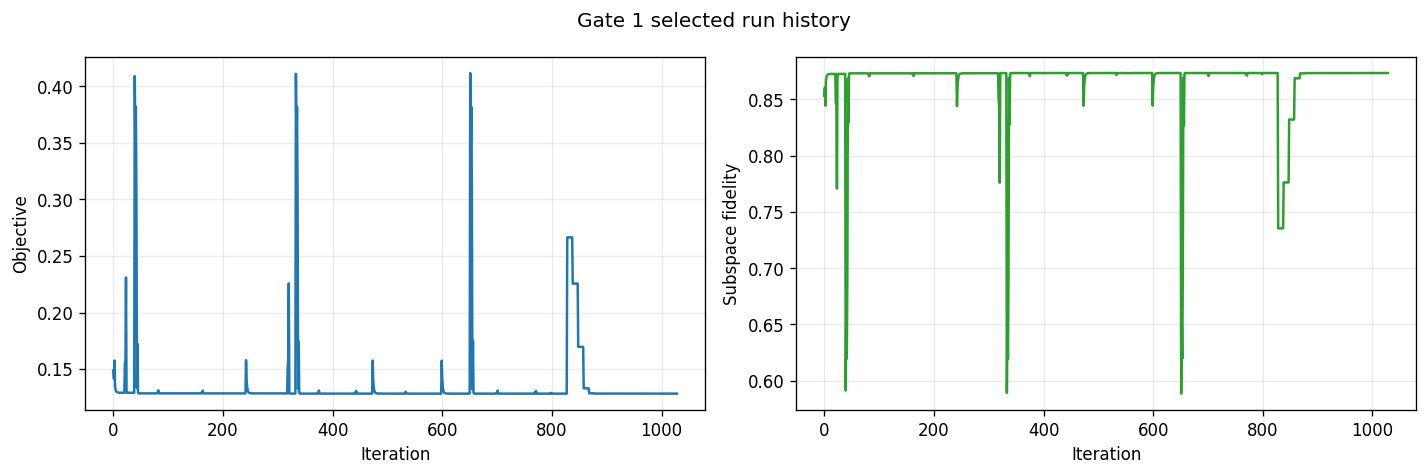

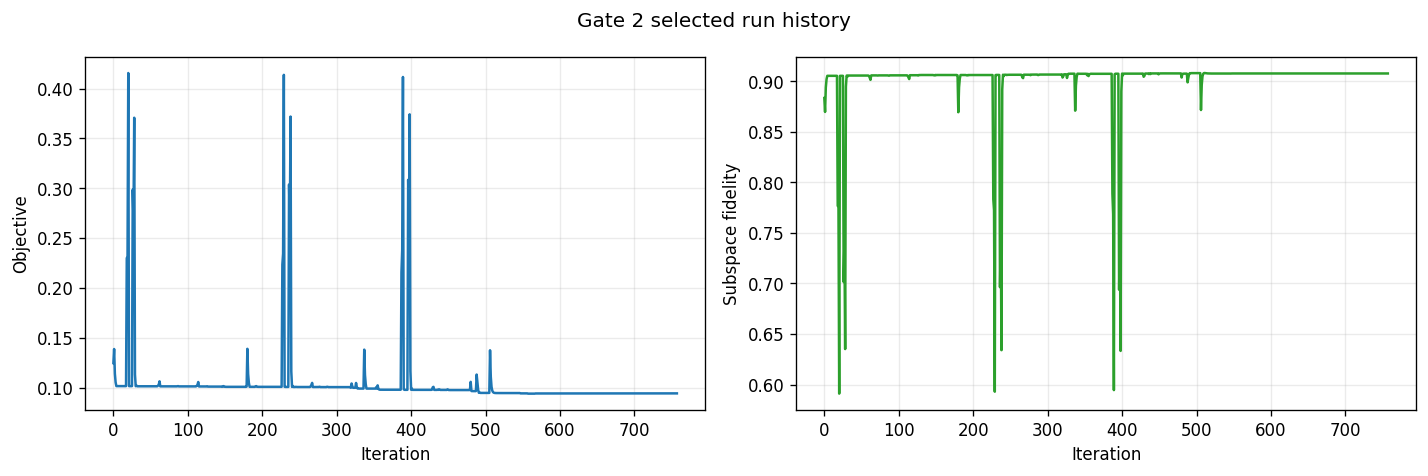

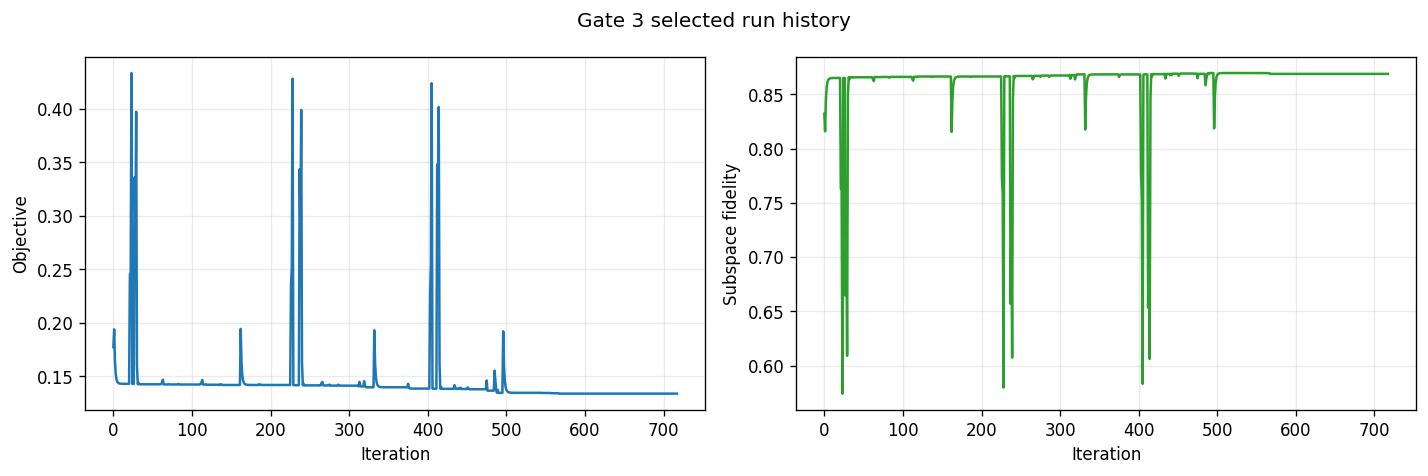

: 

In [ ]:
for result in gate_results:
    plot_selected_history(
        result["selected_point"],
        title=f"Gate {result['gate_index']} selected run history",
    )

## Notes

- `selected_duration_ns` is the duration used for the waveform overlay.
- If a gate does not cross the chosen fidelity threshold on the scanned grid, the notebook falls back to the best scanned duration for that gate.
- The gray waveform is the nominal multitone Gaussian pulse with no optimized corrections.
- The colored waveform includes the optimized amplitude, phase, and detuning corrections returned by the guarded SQR calibration.